In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn import linear_model
import seaborn as sns


df = pd.read_csv('/home/shawky/Documents/nti/actual nti/skewness/Housing.csv')
df




,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


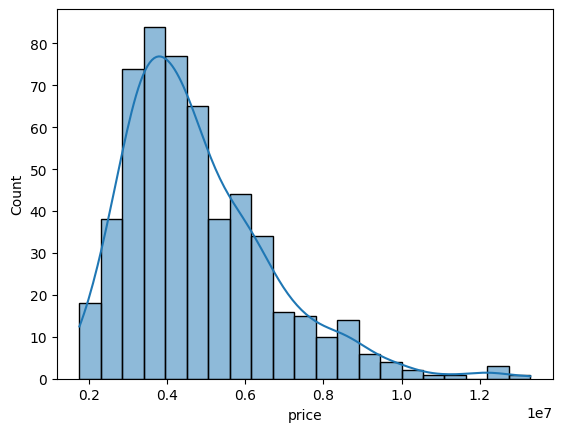

In [64]:
sns.histplot(df['price'], kde=True)
plt.show()

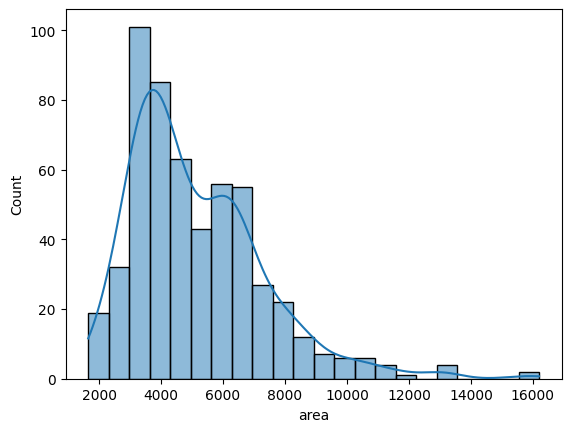

In [65]:
sns.histplot(df['area'], kde=True)
plt.show()

In [ ]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')

df['price_yj'] = transformed_data[:, 0]
df['area_yj'] = transformed_data[:, 1]

KeyError: 'price_yj'

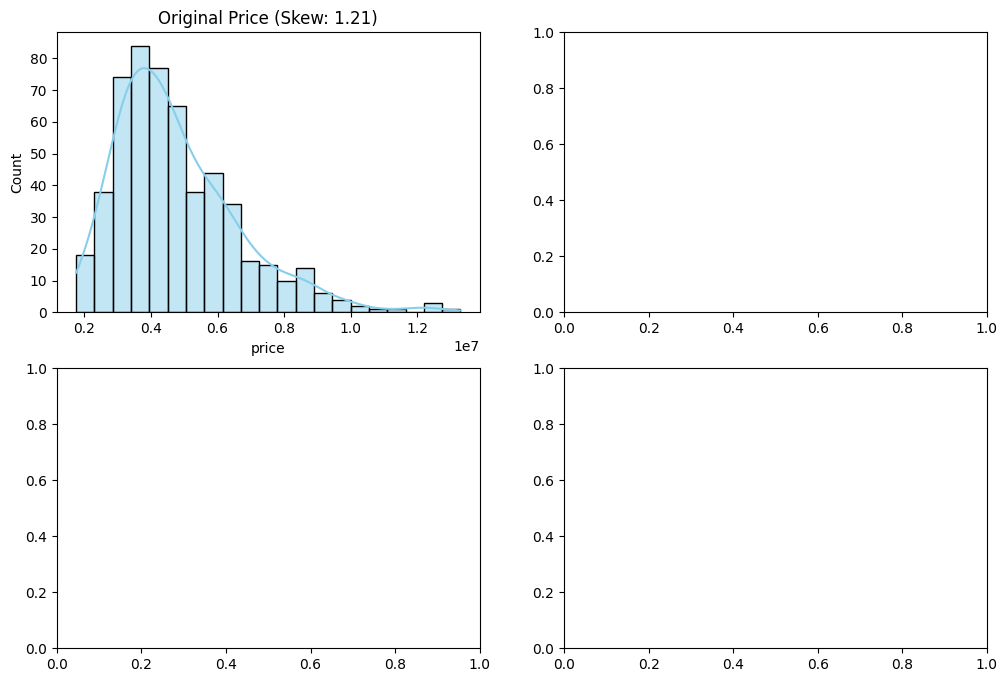

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))


sns.histplot(df['price'], kde=True, ax=axes[0, 0], color='skyblue').set(title=f"Original Price (Skew: {df['price'].skew():.2f})")
sns.histplot(df['price_yj'], kde=True, ax=axes[0, 1], color='lightgreen').set(title=f"Yeo-Johnson Price (Skew: {df['price_yj'].skew():.2f})")

sns.histplot(df['area'], kde=True, ax=axes[1, 0], color='skyblue').set(title=f"Original Area (Skew: {df['area'].skew():.2f})")
sns.histplot(df['area_yj'], kde=True, ax=axes[1, 1], color='lightgreen').set(title=f"Yeo-Johnson Area (Skew: {df['area_yj'].skew():.2f})")

plt.tight_layout()
plt.show()

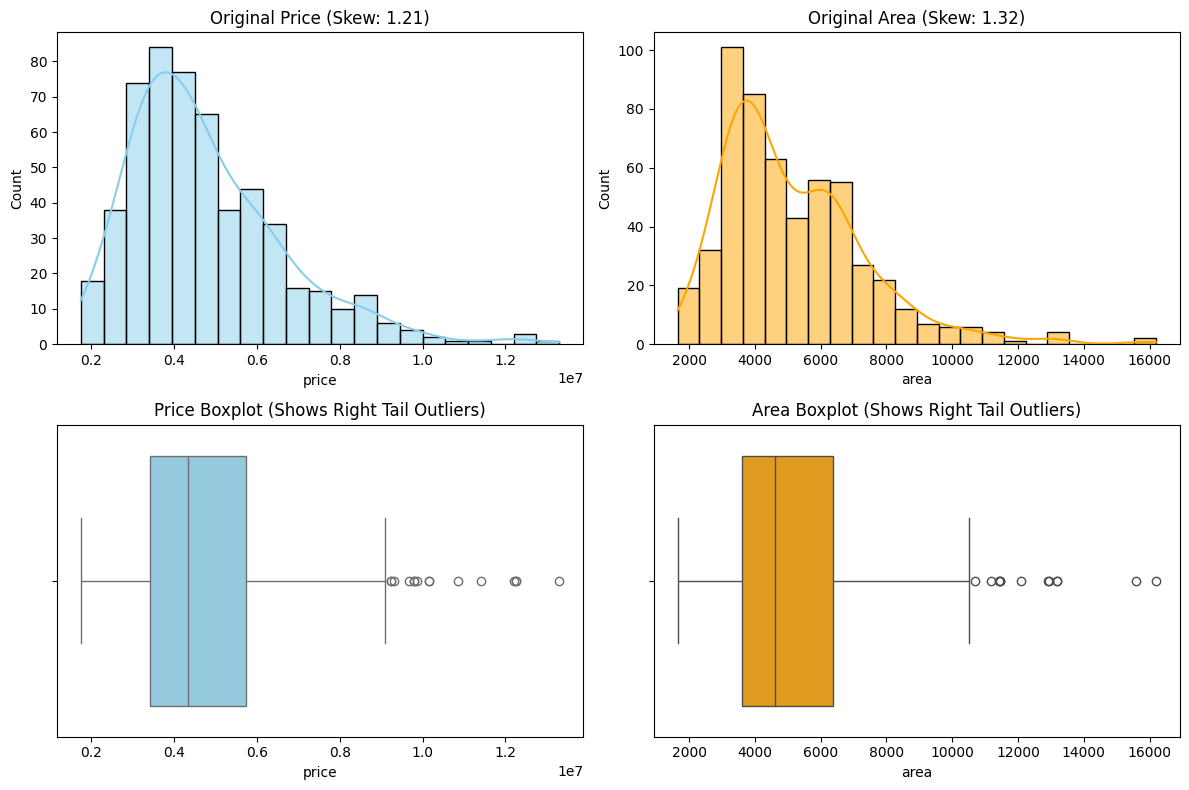

In [68]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

#price  
sns.histplot(df['price'], kde=True, ax=axes[0, 0], color='skyblue').set(
    title=f"Original Price (Skew: {df['price'].skew():.2f})"
)
sns.boxplot(x=df['price'], ax=axes[1, 0], color='skyblue').set(
    title="Price Boxplot (Shows Right Tail Outliers)"
)

# area
sns.histplot(df['area'], kde=True, ax=axes[0, 1], color='orange').set(
    title=f"Original Area (Skew: {df['area'].skew():.2f})"
)
sns.boxplot(x=df['area'], ax=axes[1, 1], color='orange').set(
    title="Area Boxplot (Shows Right Tail Outliers)"
)

plt.tight_layout()
plt.show()

In [81]:



def capping_outliers(data: pd.DataFrame
                     , columns: list
                     , method: str = 'iqr'
                     , z: float = 3
                     , whisker: float = 1.5
                     , inplace : bool = False ) -> tuple:
    if method.lower() not in ['iqr', 'zscore']:
        raise ValueError(f"you entered {method} the function use : iqr or zscore")
    
    df = data if inplace else data.copy()
    report = []
    for col in columns:
        series = df[col]

        if  not pd.api.types.is_numeric_dtype(series):
            print(f"column {col} is not numeric, skipping...")
            continue

        if method == 'iqr':
            q1 = series.quantile(0.25)
            q3 = series.quantile(0.75)
            iqr = q3 - q1
            lower_bound = q1 - whisker * iqr
            upper_bound = q3 + whisker * iqr
        else:

            mean = series.mean()
            std = series.std()
            lower_bound = mean - z * std
            upper_bound = mean + z * std

        outliers = series[(series < lower_bound) | (series > upper_bound)]
        n_outliers = len(outliers)
        pct_outliers = n_outliers / len(series) * 100
        df[col] = series.clip(lower=lower_bound, upper=upper_bound)

        report.append({
            'column': col,
            'Method': method,
            'n_outliers': n_outliers,
            'pct_outliers': pct_outliers,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound
            })
        
    return df, pd.DataFrame(report)

In [82]:
capped_df, summary_report = capping_outliers(
    df,
    columns=["price", "area", "bedrooms"],
    method="iqr",
    whisker=1.5,
    inplace=False,
)
capped_df
display(capped_df)
display(summary_report)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price_yj,area_yj
0,9205000,7420,4.0,2,3,yes,no,no,no,yes,2,yes,furnished,2.770977,1.115457
1,9205000,8960,4.0,4,4,yes,no,no,no,yes,3,no,furnished,2.578757,1.559601
2,9205000,9960,3.0,2,2,yes,no,yes,no,no,2,yes,semi-furnished,2.578757,1.804291
3,9205000,7500,4.0,2,2,yes,no,yes,no,yes,3,yes,furnished,2.572031,1.140991
4,9205000,7420,4.0,1,2,yes,yes,yes,no,yes,2,no,furnished,2.410998,1.115457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2.0,1,1,yes,no,yes,no,no,2,no,unfurnished,-2.530392,-1.167310
541,1767150,2400,3.0,1,1,no,no,no,no,no,0,no,semi-furnished,-2.620103,-1.770055
542,1750000,3620,2.0,1,1,yes,no,no,no,no,0,no,unfurnished,-2.649870,-0.672559
543,1750000,2910,3.0,1,1,no,no,no,no,no,0,no,furnished,-2.649870,-1.248611


,column,Method,n_outliers,pct_outliers,lower_bound,upper_bound
0,price,iqr,15,2.752294,-35000.0,9205000.0
1,area,iqr,12,2.201835,-540.0,10500.0
2,bedrooms,iqr,12,2.201835,0.5,4.5


<Axes: xlabel='price', ylabel='Count'>

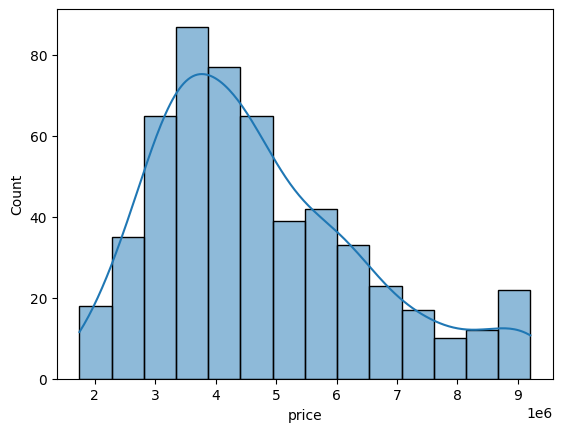

In [83]:
sns.histplot(capped_df['price'], kde=True)

<Axes: xlabel='price', ylabel='Count'>

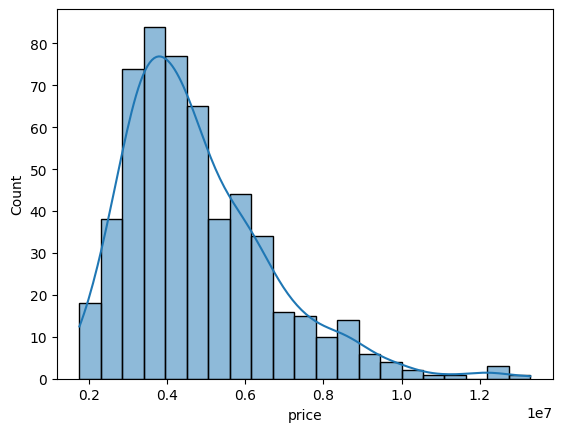

In [84]:
sns.histplot(df['price'], kde=True)

In [86]:
from feature_engine.outliers import Winsorizer

# Set up the capper
capper = Winsorizer(
    capping_method='iqr', 
    fold=1.5, 
    tail='both', 
    variables=['price', 'area', 'bedrooms']
)

# Fit to compute bounds and transform the dataframe
df_capped = capper.fit_transform(df)

# View the computed lower and upper bounds
print(capper.left_tail_caps_)
print(capper.right_tail_caps_)

{'price': -35000.0, 'area': -540.0, 'bedrooms': 0.5}
{'price': 9205000.0, 'area': 10500.0, 'bedrooms': 4.5}
